# 一、Auto-Encoder

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image

data_set = datasets.MNIST(root='./.data', train=True, transform=transforms.ToTensor(), download=True)
print(data_set.data.shape)

# img, label = data_set[0]
# plt.imshow(img.squeeze(), cmap="gray")
# plt.axis("off")
# plt.show()


 39%|███▉      | 3.87M/9.91M [00:11<00:15, 400kB/s] 

In [83]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)

class Encoder(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_linear=1):
        super(Encoder, self).__init__()
        self.fc_in = torch.nn.Linear(input_size, hidden_size)
        self.fc_out = torch.nn.Linear(hidden_size, output_size)
        self.n_liner = torch.nn.ModuleList([torch.nn.Linear(hidden_size, hidden_size) for _ in range(n_linear)])

    def forward(self, x):
        x = F.relu(self.fc_in(x))
        for liner in self.n_liner:
            x = F.relu(liner(x))
        x = self.fc_out(x)
        return x

class Decoder(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_linear=1):
        super(Decoder, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return x

embed_size = 2
n_fc = 1
mlp_input_size = data_set.data.shape[-1] * data_set.data.shape[-2]
hidden_size = 256
lr = 0.0005
epoch = 20


exps = {
    "mlp": {
        "encoder": Encoder(mlp_input_size, hidden_size, embed_size, n_fc),
        "decoder": Decoder(embed_size, hidden_size, mlp_input_size, n_fc),
    }
}

train_set, test_set = random_split(data_set, [0.9, 0.1])
data_loader = DataLoader(train_set, batch_size=100, shuffle=True)


for name, exp in exps.items():
    encoder = exp["encoder"]
    decoder = exp["decoder"]

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    for ep in range(epoch):
        for step, data in enumerate(data_loader):
            optimizer.zero_grad()
            imgs, labels = data

            imgs = imgs.reshape(imgs.shape[0], -1)

            embed = encoder(imgs)
            origin = decoder(embed)

            loss = F.mse_loss(origin, imgs)
            loss.backward()
            optimizer.step()
            if step % 100 == 0:
                print(ep, step, loss.item())

    sample_generator = torch.Generator().manual_seed(123)

    # 随机抽取 8 个测试集下标

0 0 0.10970034450292587
0 100 0.06593310087919235
0 200 0.05823285132646561
0 300 0.05254998058080673
0 400 0.0501096248626709
0 500 0.04723789542913437
1 0 0.04966936632990837
1 100 0.047588642686605453
1 200 0.0488533191382885
1 300 0.052953679114580154
1 400 0.046978265047073364
1 500 0.04462137445807457
2 0 0.045812226831912994
2 100 0.04816002771258354
2 200 0.046519067138433456
2 300 0.04273824021220207
2 400 0.04501049965620041
2 500 0.04445945844054222
3 0 0.04506523907184601
3 100 0.04575075954198837
3 200 0.04217506945133209
3 300 0.040759045630693436
3 400 0.042590267956256866
3 500 0.04030565917491913
4 0 0.0406581349670887
4 100 0.04534880444407463
4 200 0.0437559112906456
4 300 0.04304465278983116
4 400 0.042287759482860565
4 500 0.04265442118048668
5 0 0.04463161528110504
5 100 0.0418921634554863
5 200 0.04139725863933563
5 300 0.043056875467300415
5 400 0.043135371059179306
5 500 0.04220173880457878
6 0 0.038533471524715424
6 100 0.043584179133176804
6 200 0.04369716718

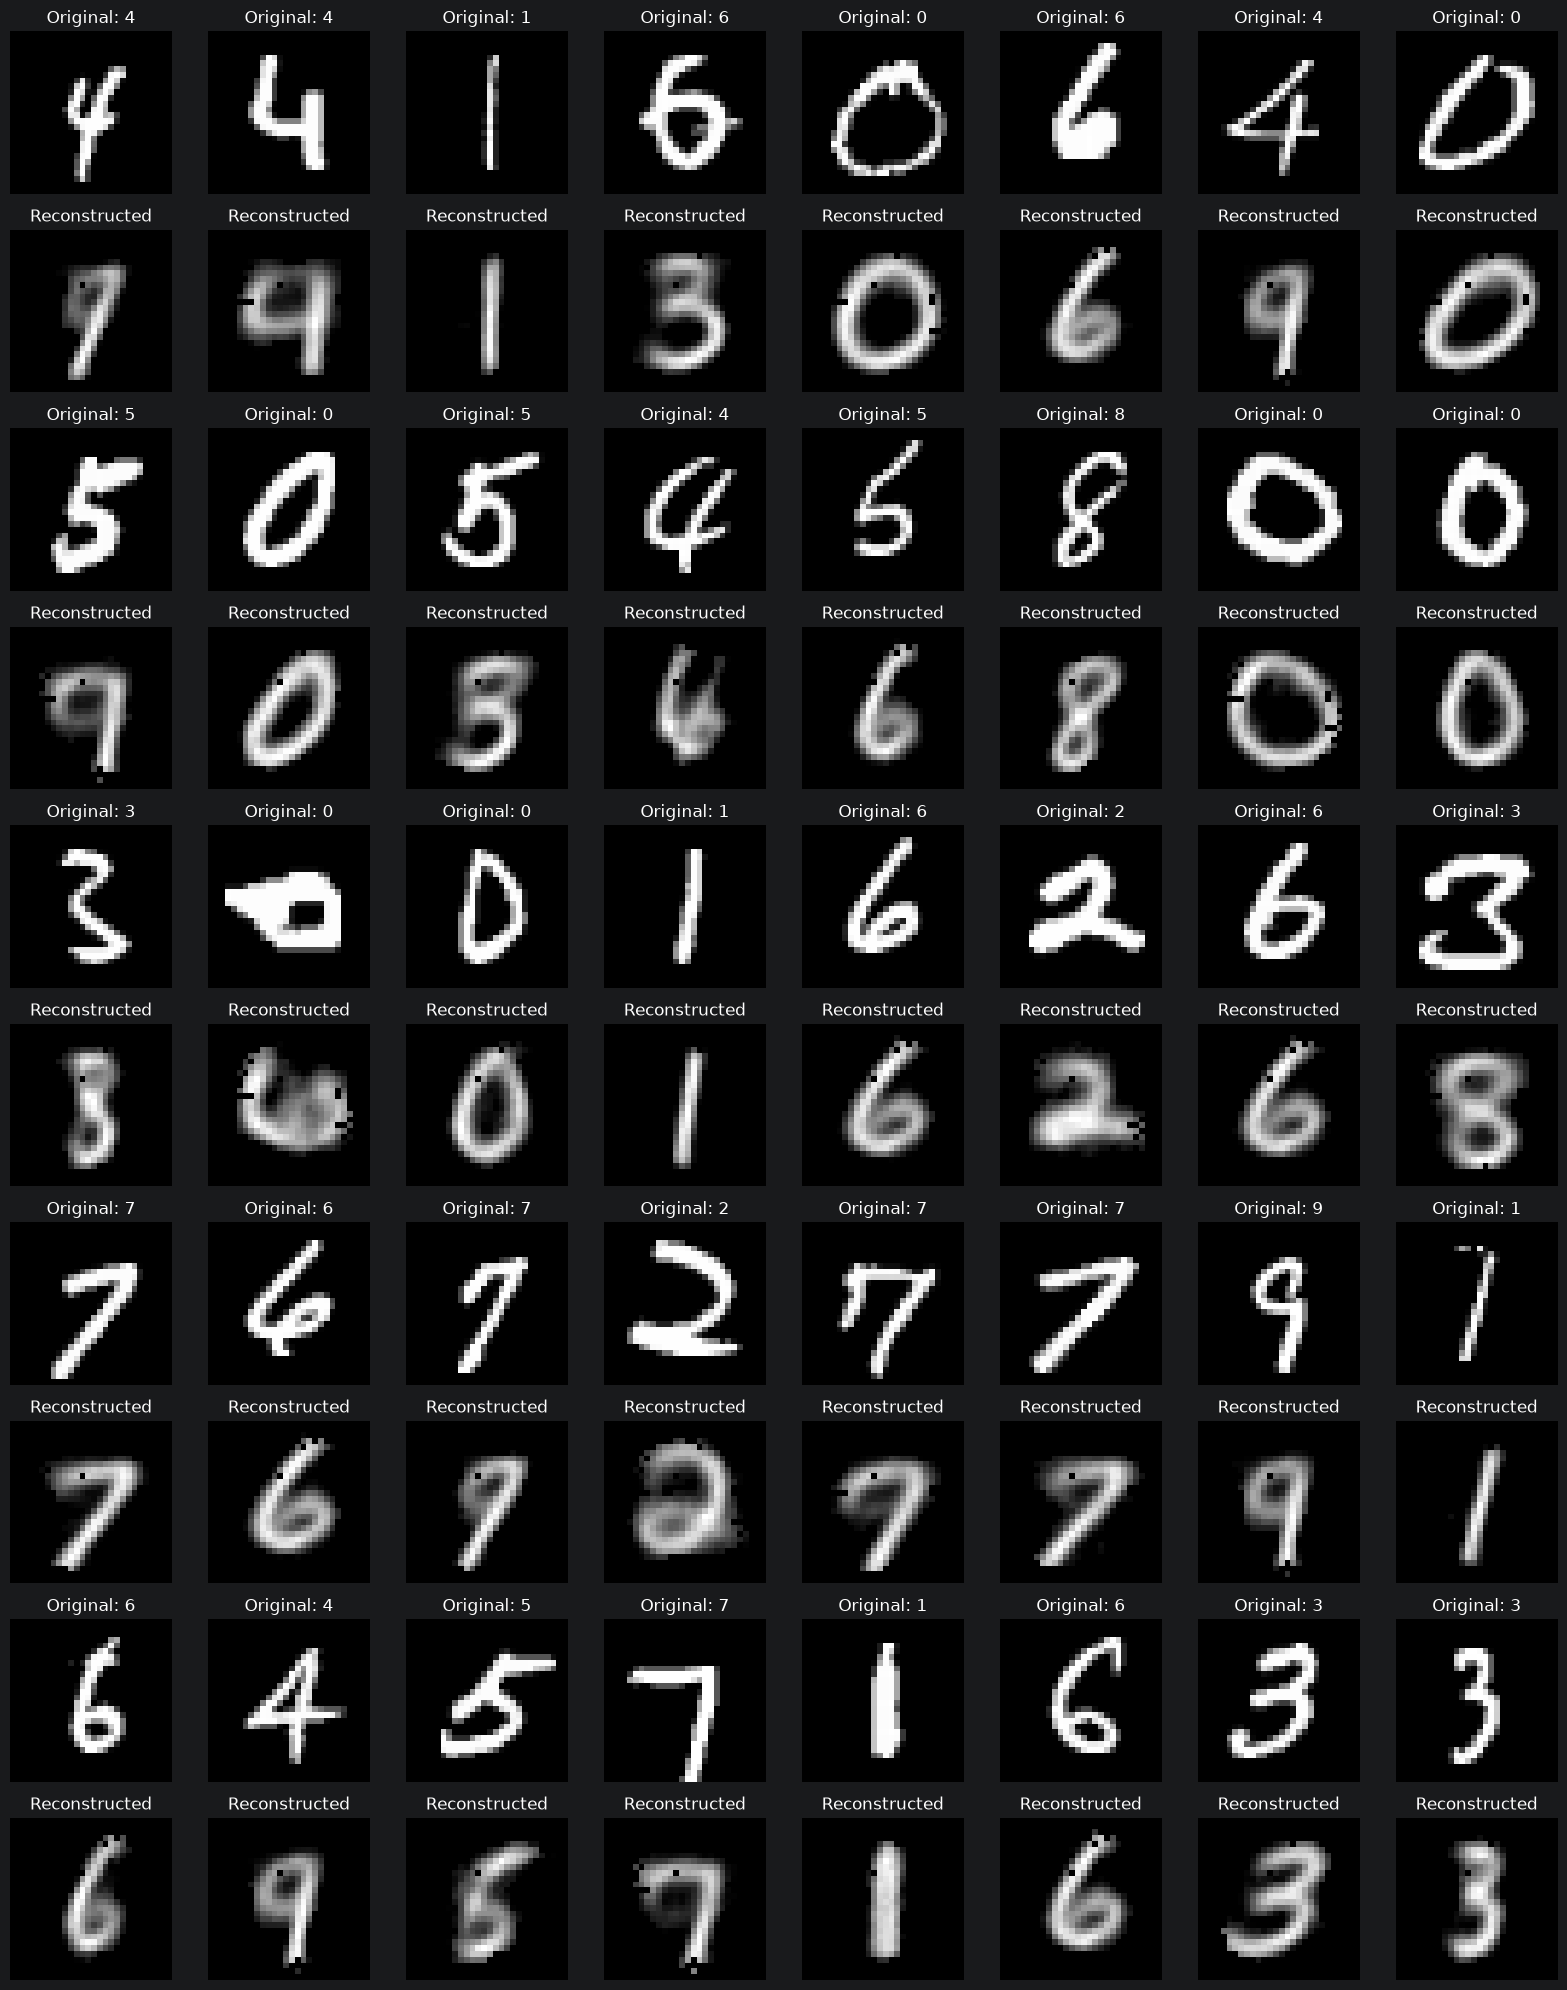

In [89]:
num_images = 40
num_cols = 8
num_rows = (num_images + num_cols - 1) // num_cols

for name, exp in exps.items():
    encoder = exp["encoder"]
    decoder = exp["decoder"]

    indices = torch.randperm(
        len(test_set),
        generator=sample_generator
    )[:num_images]

    fig, axes = plt.subplots(
        num_rows * 2,
        num_cols,
        figsize=(16, 4 * num_rows)
    )

    for i, idx in enumerate(indices):
        img, label = test_set[idx]

        img_flat = img.reshape(1, -1)

        with torch.no_grad():
            reconstruct = decoder(encoder(img_flat))

        reconstruct = reconstruct.reshape(28, 28)

        # 当前图片属于第几组（每组8张）
        row = i // num_cols
        col = i % num_cols

        # 原图
        axes[row * 2, col].imshow(img.squeeze(), cmap="gray")
        axes[row * 2, col].set_title(f"Original: {label}")
        axes[row * 2, col].axis("off")

        # 重建图
        axes[row * 2 + 1, col].imshow(reconstruct, cmap="gray")
        axes[row * 2 + 1, col].set_title("Reconstructed")
        axes[row * 2 + 1, col].axis("off")

    plt.tight_layout()
    plt.show()